In [1]:
import pandas as pd

## Main results

In [3]:
main_res = pd.read_csv("results/tabulated_results.csv")

In [7]:
main_res = main_res[~main_res['split_name'].isin(['split2', 'split3'])]
main_res = main_res[main_res['model_name']!='whisper-small']
main_res

,lang,model_name,split_name,wer,cer,per,phoneme_fit_logx0,phoneme_fit_r2
0,Archi,Qwen2-Audio-7B-Instruct,split,0.579,0.163,0.180,1.673,0.680
1,Archi,Qwen2-Audio-7B-Instruct,split_cyrillic,0.539,0.156,0.166,1.769,0.399
2,Archi,Qwen2.5-Omni-7B,split,0.705,0.184,0.199,1.826,0.695
3,Archi,Qwen2.5-Omni-7B,split_cyrillic,0.708,0.212,0.219,1.910,0.598
4,Archi,custom,split,0.479,0.116,0.122,1.422,0.659
5,Archi,custom,split_lm,0.465,0.116,0.122,1.399,0.615
6,Archi,custom,split_noavg,0.462,0.116,0.123,1.129,0.428
7,Archi,custom,split_noinit,0.593,0.138,0.147,1.515,0.713
8,Archi,custom,zero_shot,1.000,0.544,0.558,2.722,0.693
9,Archi,gpt-4o-transcribe,split,0.982,0.435,0.436,2.452,0.539


In [15]:
def map_suffix(split_name):
    if '_' not in split_name:
        return ''
    if split_name == 'zero_shot':
        return '-zs'
    mapping = {'cyrillic': '-cyrl', 'noinit': '-noinit', 'noavg': '-cpy1', 'lm': '-lm'}
    return mapping[split_name.split('_')[1]]

def map_model(model_name):
    if 'wav2vec2' in model_name:
        return 'wav2vec2-large-ipa'
    if model_name == 'custom':
        return 'w2v2l-custom'
    return model_name


def model_id(row):
    model = map_model(row['model_name'])
    suffix = map_suffix(row['split_name'])
    if 'custom' in model:
        if suffix not in ['-noinit', '-cpy1']:
            suffix = '-avg' + suffix
    if suffix == '-noinit':
        suffix = ''
    if suffix == '':
        return model
    return model + suffix


main_res['model_id'] = main_res.apply(model_id, axis =1)
main_res

,lang,model_name,split_name,wer,cer,per,phoneme_fit_logx0,phoneme_fit_r2,model_id
0,Archi,Qwen2-Audio-7B-Instruct,split,0.579,0.163,0.180,1.673,0.680,Qwen2-Audio-7B-Instruct
1,Archi,Qwen2-Audio-7B-Instruct,split_cyrillic,0.539,0.156,0.166,1.769,0.399,Qwen2-Audio-7B-Instruct-cyrl
2,Archi,Qwen2.5-Omni-7B,split,0.705,0.184,0.199,1.826,0.695,Qwen2.5-Omni-7B
3,Archi,Qwen2.5-Omni-7B,split_cyrillic,0.708,0.212,0.219,1.910,0.598,Qwen2.5-Omni-7B-cyrl
4,Archi,custom,split,0.479,0.116,0.122,1.422,0.659,w2v2l-custom-avg
5,Archi,custom,split_lm,0.465,0.116,0.122,1.399,0.615,w2v2l-custom-avg-lm
6,Archi,custom,split_noavg,0.462,0.116,0.123,1.129,0.428,w2v2l-custom-cpy1
7,Archi,custom,split_noinit,0.593,0.138,0.147,1.515,0.713,w2v2l-custom
8,Archi,custom,zero_shot,1.000,0.544,0.558,2.722,0.693,w2v2l-custom-avg-zs
9,Archi,gpt-4o-transcribe,split,0.982,0.435,0.436,2.452,0.539,gpt-4o-transcribe


In [19]:
model_ids = ['wav2vec2-large-ipa-zs', 'wav2vec2-large-ipa', 'w2v2l-custom-avg-zs',\
               'w2v2l-custom', 'w2v2l-custom-cpy1', 'w2v2l-custom-avg',\
               'w2v2l-custom-avg-lm', 'whisper-large-v3', 'whisper-large-v3-cyrl',\
              'Qwen2-Audio-7B-Instruct', 'Qwen2-Audio-7B-Instruct-cyrl', 'Qwen2.5-Omni-7B', 'Qwen2.5-Omni-7B-cyrl', 'gpt-4o-transcribe']

In [20]:
model_ids

['wav2vec2-large-ipa-zs',
 'wav2vec2-large-ipa',
 'w2v2l-custom-avg-zs',
 'w2v2l-custom',
 'w2v2l-custom-cpy1',
 'w2v2l-custom-avg',
 'w2v2l-custom-avg-lm',
 'whisper-large-v3',
 'whisper-large-v3-cyrl',
 'Qwen2-Audio-7B-Instruct',
 'Qwen2-Audio-7B-Instruct-cyrl',
 'Qwen2.5-Omni-7B',
 'Qwen2.5-Omni-7B-cyrl',
 'gpt-4o-transcribe']

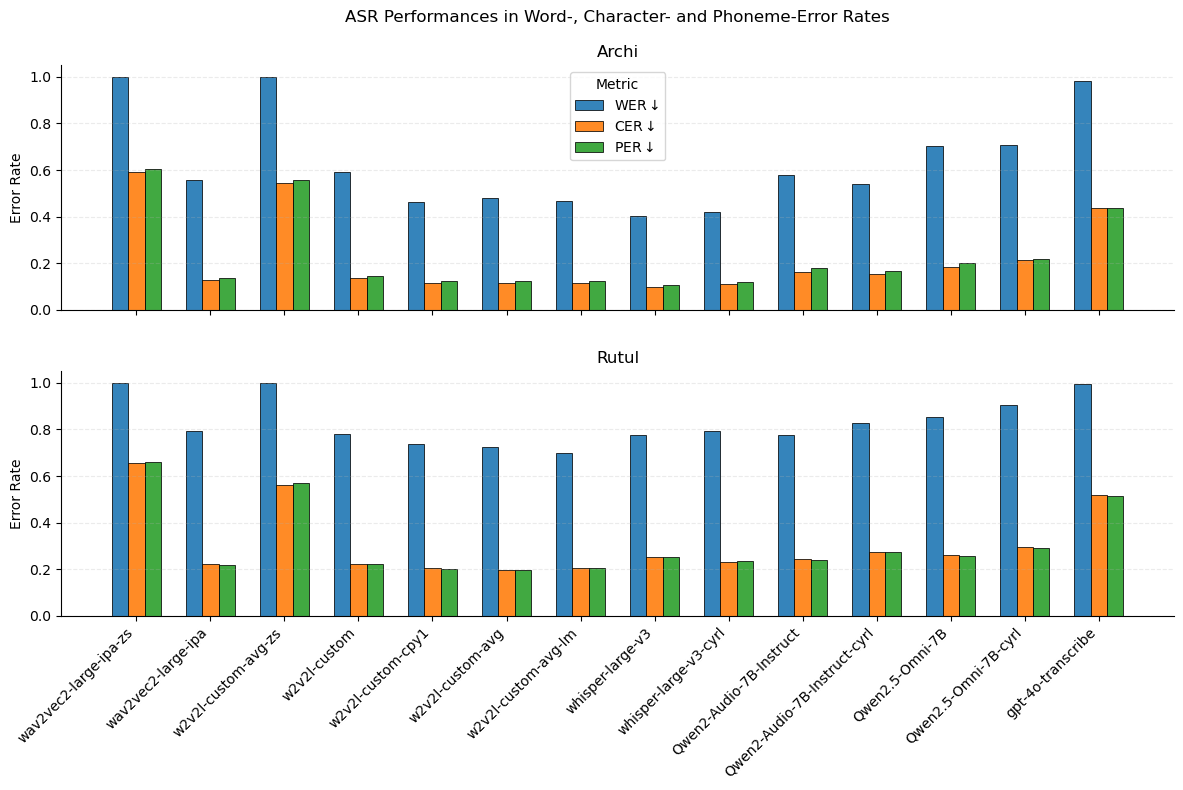

In [37]:
import matplotlib.pyplot as plt
import numpy as np
# Desired model order
# model_ids = [...]

# Fixed colors
metric_colors = {
    "wer": "#1f77b4",  # blue
    "cer": "#ff7f0e",  # orange
    "per": "#2ca02c",  # green
}

metrics = ["wer", "cer", "per"]

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)
plt.style.use("tableau-colorblind10")

for ax, lang in zip(axes, ["Archi", "Rutul"]):

    df = (
        main_res[main_res["lang"] == lang]
        .copy()
    )

    # Ensure desired order
    df["model_id"] = pd.Categorical(
        df["model_id"],
        categories=model_ids,
        ordered=True
    )
    df = df.sort_values("model_id")

    x = np.arange(len(df))
    width = 0.22

    for i, metric in enumerate(metrics):
        ax.bar(
            x + (i - 1) * width,
            df[metric],
            width=width,
            color=metric_colors[metric],
            label=metric.upper() + "$\\downarrow$" if lang == "Archi" else None,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )

    ax.set_title("ASR Performances in Word-, Character- and Phoneme-Error Rates\n\n"+lang if lang == "Archi" else "\n"+lang)
    ax.set_ylabel("Error Rate")
    ax.grid(axis="y", linestyle='--', alpha=0.25)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# X ticks only on bottom subplot
axes[-1].set_xticks(np.arange(len(df)))
axes[-1].set_xticklabels(
    df["model_id"],
    rotation=45,
    ha="right"
)

# Single legend
axes[0].legend(title="Metric")

plt.tight_layout()
plt.savefig("results/asr_res.png", dpi=300)
plt.show()

## Phoneme-Complexity vs Performance

In [64]:
ph_cat_wise_dfs = pd.read_csv("results/phoneme_catwise_Archi.tsv", sep='\t'), pd.read_csv("results/phoneme_catwise_Rutul.tsv", sep='\t')

In [65]:
for df in ph_cat_wise_dfs:
    df.rename(columns={"model":"model_name", "split":"split_name"}, inplace=True)
    bool_series = ~df['split_name'].isin(['split2', 'split3'])
    df.query("@bool_series", inplace=True)
    bool_series = df['model_name']!='whisper-small'
    df.query("@bool_series", inplace=True)
    df['model_id'] = df.apply(model_id, axis=1)

In [66]:
from scipy.stats import pearsonr

def compute_r(row, cols, lens):
    x = []
    y = []
    for c,l in zip(cols, lens):
        x.append(row[c])
        y.append(l)
    return pearsonr(x, y).statistic
    
for df in ph_cat_wise_dfs:
    cols = [c for c in df.columns if c not in ['model_name', 'split_name', 'model_id']]
    lens = [len(c.split()[0]) for c in cols]
    df["pearsonr"] = df.apply(lambda x: compute_r(x, cols, lens), axis=1)
    

In [68]:
ph_cat_wise_dfs = [df[["model_id", "pearsonr"]] for df in ph_cat_wise_dfs]

In [70]:
for i, df in enumerate(ph_cat_wise_dfs):
    if i == 0:
        lang = "Archi"
    else:
        lang = "Rutul"
    df["lang"] = df.apply(lambda x: lang, axis=1)

/tmp/ipykernel_493052/2710704892.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["lang"] = df.apply(lambda x: lang, axis=1)


In [77]:
pearson_r = pd.concat(ph_cat_wise_dfs).reset_index(drop=True)

In [78]:
pearson_r

,model_id,pearsonr,lang
0,w2v2l-custom-avg,-0.360120,Archi
1,w2v2l-custom-avg-lm,-0.388115,Archi
2,w2v2l-custom-cpy1,-0.089280,Archi
3,w2v2l-custom,-0.241740,Archi
4,w2v2l-custom-avg-zs,-0.646551,Archi
5,gpt-4o-transcribe,-0.759815,Archi
6,Qwen2-Audio-7B-Instruct,-0.206910,Archi
7,Qwen2-Audio-7B-Instruct-cyrl,-0.178882,Archi
8,Qwen2.5-Omni-7B,-0.460783,Archi
9,Qwen2.5-Omni-7B-cyrl,-0.595924,Archi


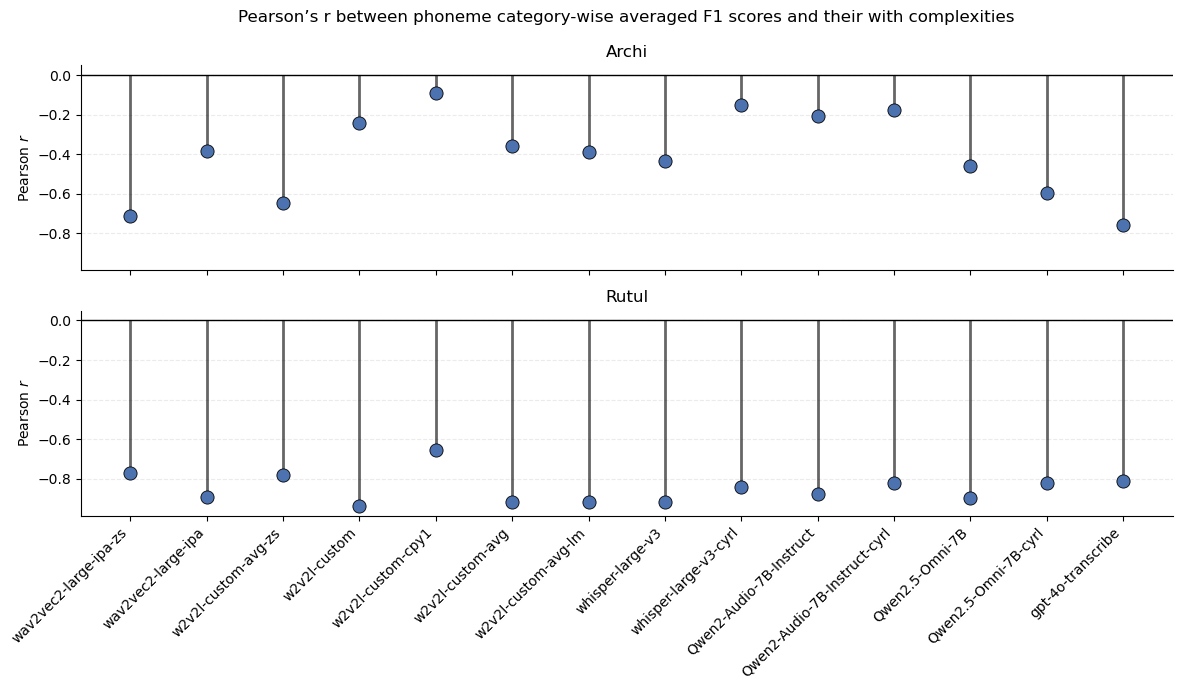

In [84]:
# Desired order of models on x-axis
# model_ids = [...]

plt.style.use("tableau-colorblind10")

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 7),
    sharex=True
)

point_color = "#4C72B0"

for ax, lang in zip(axes, ["Archi", "Rutul"]):

    df = pearson_r[pearson_r["lang"] == lang].copy()

    # enforce model order
    df["model_id"] = pd.Categorical(
        df["model_id"],
        categories=model_ids,
        ordered=True
    )

    df = df.sort_values("model_id")

    x = np.arange(len(df))

    # lollipop stems
    ax.vlines(
        x=x,
        ymin=0,
        ymax=df["pearsonr"],
        color="black",
        alpha=0.6,
        linewidth=2
    )

    # lollipop heads
    ax.scatter(
        x,
        df["pearsonr"],
        s=90,
        color=point_color,
        edgecolors="black",
        linewidths=0.6,
        zorder=3
    )

    # zero reference line
    ax.axhline(
        0,
        color="black",
        linewidth=1
    )

    ax.set_title(lang if lang == "Rutul" else "Pearson’s r between phoneme category-wise averaged F1 scores and their with complexities\n\n"+lang)
    ax.set_ylabel("Pearson $r$")

    # nice grid
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )
    ax.set_axisbelow(True)

    # cleaner appearance
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


# x-axis labels on bottom subplot only
axes[-1].set_xticks(np.arange(len(df)))
axes[-1].set_xticklabels(
    df["model_id"],
    rotation=45,
    ha="right"
)

# same y-range for easy comparison
all_r = pearson_r["pearsonr"]
ymin = min(-0.55, all_r.min() - 0.05)
ymax = 0.05

for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.savefig("results/pearsonr.png", dpi=300)
plt.show()